<a href="https://colab.research.google.com/github/Venni2911/LogicMojo-AI-ML-Sept25-VenniRaj/blob/main/Copy_of_CNN_under_the_Hood.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN under the HOOD

**Agenda**
* Popular CNN Architechure.
  * AlexNet.
  * VGG.
  * VGG 16.
  * VGG 19.
* Transfer Learning.


## Popular CNN Architechure

Popular CNN Architecture
AlexNet and the VGG series, including VGG16 and VGG19, stand as pillars in the realm of Convolutional Neural Networks (CNNs) for computer vision tasks. AlexNet, introduced in 2012 by Krizhevsky, Sutskever, and Hinton, marked a watershed moment by demonstrating the power of deep learning in winning the ImageNet competition. Its design, featuring five convolutional layers and three fully connected layers, revolutionized the field. Following this, the VGG architecture, developed by Simonyan and Zisserman in 2014, presented a straightforward yet effective approach with uniform 3x3 convolutional filters and max-pooling layers. VGG16 and VGG19, extensions of VGG, furthered this simplicity, offering deeper networks with up to 19 layers while maintaining ease of understanding and implementation. These architectures served as benchmarks for image classification tasks and laid the groundwork for subsequent advancements in CNN design, setting a standard for both performance and elegance in deep learning architectures.

### Alexnet

AlexNet stands as a pioneering milestone in the domain of deep learning, particularly in the realm of computer vision. Introduced in 2012 by Alex Krizhevsky, Ilya Sutskever, and Geoffrey Hinton, this Convolutional Neural Network (CNN) architecture shattered previous performance benchmarks, notably by winning the ImageNet Large Scale Visual Recognition Challenge (ILSVRC) in 2012 by a significant margin. What set AlexNet apart were its innovative design choices, including the utilization of Rectified Linear Units (ReLU) as activation functions, local response normalization (LRN) for regularization, dropout for reducing overfitting, and data augmentation techniques. Comprising five convolutional layers followed by max-pooling layers and topped with three fully connected layers, AlexNet was instrumental in showcasing the potential of deep learning for image classification tasks. Its success paved the way for the proliferation of deep CNNs and ignited a renaissance in the field of artificial intelligence.

One key feature of AlexNet, which significantly contributed to its success and impact in the field of deep learning, is the utilization of Rectified Linear Units (ReLU) as the activation function instead of traditional activation functions like tanh or sigmoid.

#### Architecture


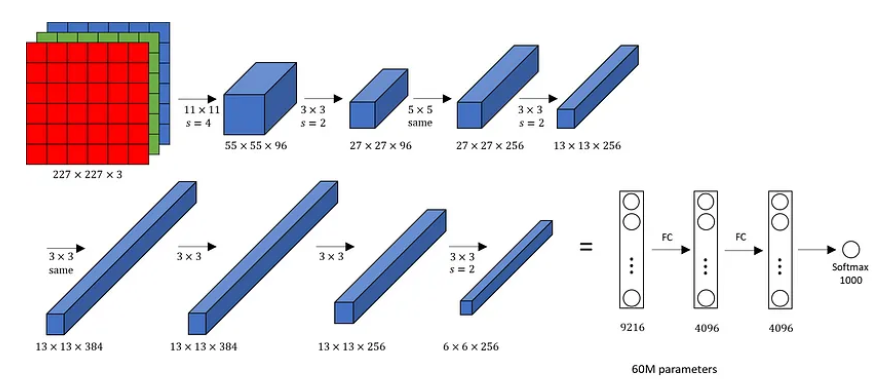

* **Input Layer:** AlexNet takes an input image of size 224x224x3 (RGB channels).

* **Convolutional Layers:** The first five layers are convolutional layers, responsible for learning hierarchical features from the input images.

  * **Conv1:** 96 filters of size 11x11x3, with a stride of 4, followed by ReLU activation and LRN.

  * **Conv2:** 256 filters of size 5x5x48, with a stride of 1, followed by ReLU activation and LRN.

  * **Conv3:** 384 filters of size 3x3x256, with a stride of 1, followed by ReLU activation.

  * **Conv4:** 384 filters of size 3x3x192, with a stride of 1, followed by ReLU activation.

  * **Conv5:** 256 filters of size 3x3x192, with a stride of 1, followed by ReLU activation.
  
  * **Max Pooling Layers:** Max-pooling layers follow some of the convolutional layers to down-sample the feature maps and reduce spatial dimensions.
* **Max Pooling (after Conv1, Conv2, and Conv5):** Max-pooling with a filter size of 3x3 and a stride of 2.
Fully Connected Layers: The last three layers of AlexNet are fully connected layers.

  * **FC6:** 4096 neurons with ReLU activation and dropout (dropout rate of 0.5).

  * **FC7:** 4096 neurons with ReLU activation and dropout (dropout rate of 0.5).
  
  * **FC8 (Output Layer):** 1000 neurons corresponding to the 1000 classes in the ImageNet dataset, followed by a softmax activation function for classification.
* **Output Layer:** The final layer outputs the predicted probabilities for each class in the ImageNet dataset.

AlexNet, a groundbreaking architecture in deep learning, ushered in a new era with its innovative utilization of GPUs to enhance training performance. Comprising 5 convolutional layers, 3 max-pooling layers, 2 normalization layers, 2 fully connected layers, and 1 SoftMax layer, AlexNet boasts over 60 million parameters. Unlike its predecessors, AlexNet embraced ReLU activation functions over tanh, accelerating training sixfold. Operating on a fixed input size, usually stated as 224x224x3, augmented by padding to 227x227x3, AlexNet's design aimed to reduce overfitting via strategies such as data augmentation—leveraging techniques like flipping, jittering, cropping, and color normalization. Employing a batch size of 128 and SGD Momentum as the learning algorithm, AlexNet epitomized efficiency. Max pooling, a hallmark of CNN architectures, was executed using 3x3 pooling windows with a stride of 2, fostering abstraction and reducing spatial dimensions. This overlapped pooling approach notably decreased error rates. The embrace of ReLU non-linearity facilitated faster training, as evidenced by a sixfold increase in speed compared to tanh-based networks. Data augmentation, including mirroring and random cropping, further enriched the training dataset, mitigating overfitting. Dropout, a pivotal technique, randomly pruned neurons during training, bolstering robustness and combating overfitting. Thus, AlexNet's amalgamation of GPU acceleration, ReLU activation, max pooling, and strategic data augmentation set a new standard, heralding the deep learning revolution.

#### Basic code Implementation of AlexNet Architecture

In [ ]:
import tensorflow as tf

def alexnet(input_shape=(224, 224, 3), num_classes=1000):
    # Define the Sequential model
    model = tf.keras.Sequential([
        # Convolutional layers
        # First convolutional layer with 96 filters, kernel size (11, 11), and ReLU activation
        tf.keras.layers.Conv2D(96, (11, 11), strides=(4, 4), activation='relu', input_shape=input_shape),
        # Max pooling layer with pool size (3, 3) and stride (2, 2)
        tf.keras.layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),
        # Second convolutional layer with 256 filters, kernel size (5, 5), and ReLU activation
        tf.keras.layers.Conv2D(256, (5, 5), padding='same', activation='relu'),
        # Max pooling layer
        tf.keras.layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),
        # Third convolutional layer with 384 filters, kernel size (3, 3), and ReLU activation
        tf.keras.layers.Conv2D(384, (3, 3), padding='same', activation='relu'),
        # Fourth convolutional layer with 384 filters, kernel size (3, 3), and ReLU activation
        tf.keras.layers.Conv2D(384, (3, 3), padding='same', activation='relu'),
        # Fifth convolutional layer with 256 filters, kernel size (3, 3), and ReLU activation
        tf.keras.layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        # Max pooling layer
        tf.keras.layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),

        # Fully connected layers
        # Flatten layer to convert 2D feature maps to 1D
        tf.keras.layers.Flatten(),
        # First fully connected layer with 4096 neurons and ReLU activation
        tf.keras.layers.Dense(4096, activation='relu'),
        # Dropout layer with dropout rate of 0.5 to prevent overfitting
        tf.keras.layers.Dropout(0.5),
        # Second fully connected layer with 4096 neurons and ReLU activation
        tf.keras.layers.Dense(4096, activation='relu'),
        # Dropout layer
        tf.keras.layers.Dropout(0.5),
        # Output layer with num_classes neurons and softmax activation for classification
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Instantiate the AlexNet model
model = alexnet()

# Print model summary
model.summary()


### VGG

The Visual Geometry Group (VGG) network is a seminal deep learning architecture that significantly advanced the field of computer vision. Developed by the Visual Geometry Group at the University of Oxford, VGG was introduced in the paper titled "Very Deep Convolutional Networks for Large-Scale Image Recognition" by Karen Simonyan and Andrew Zisserman in 2014.

VGG is renowned for its simplicity and effectiveness. It demonstrated that increasing the depth of convolutional neural networks (CNNs) can lead to improved performance on image classification tasks. The key innovation of the VGG architecture lies in its uniform structure, which consists of stacking multiple convolutional layers of relatively small filter sizes (3x3) followed by max-pooling layers.

Here are some key features of the VGG architecture:

1. **Uniform Architecture**: VGG architectures maintain a consistent pattern of stacking convolutional layers with 3x3 filters and max-pooling layers. This uniformity simplifies the design and implementation of the network.

2. **Depth**: VGG networks are characterized by their depth, which refers to the number of layers. The original VGG network proposed two variants: VGG16, with 16 weight layers (13 convolutional layers and 3 fully connected layers), and VGG19, with 19 weight layers (16 convolutional layers and 3 fully connected layers).

3. **Small Filter Sizes**: VGG primarily uses 3x3 convolutional filters, which are small yet effective for capturing local spatial patterns in images. By stacking multiple layers with small filters, VGG can learn more complex features.

4. **Max-Pooling**: Max-pooling layers are interspersed between convolutional layers to down-sample feature maps and reduce spatial dimensions. This helps in capturing the most relevant information while increasing the receptive field.

5. **Fully Connected Layers**: The convolutional layers in VGG are followed by fully connected layers, which perform high-level reasoning and decision-making based on the extracted features.

6. **ReLU Activation**: VGG employs Rectified Linear Unit (ReLU) activation functions after each convolutional layer, which introduce non-linearity and help in learning complex representations.

VGG achieved remarkable performance on various image classification benchmarks, including the ImageNet Large Scale Visual Recognition Challenge (ILSVRC) dataset. Its simplicity, along with its ability to capture rich features from images, has made VGG a foundational architecture in the field of deep learning and computer vision.


#### Architecture


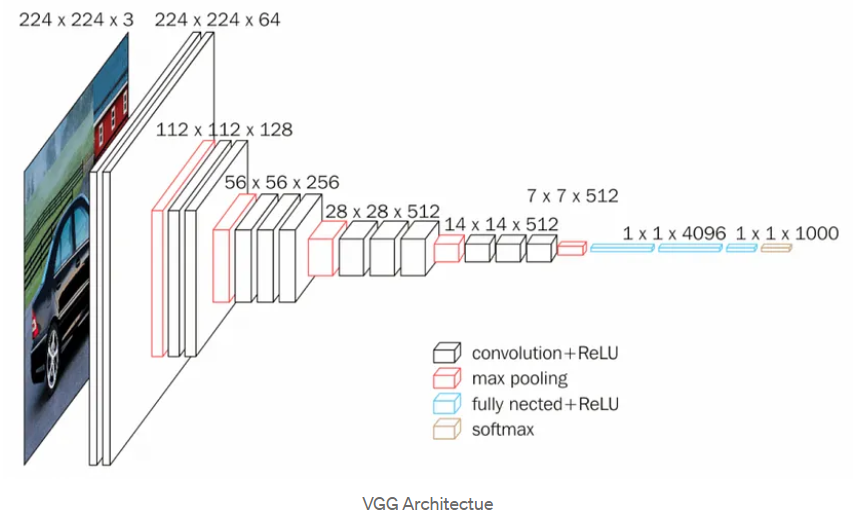

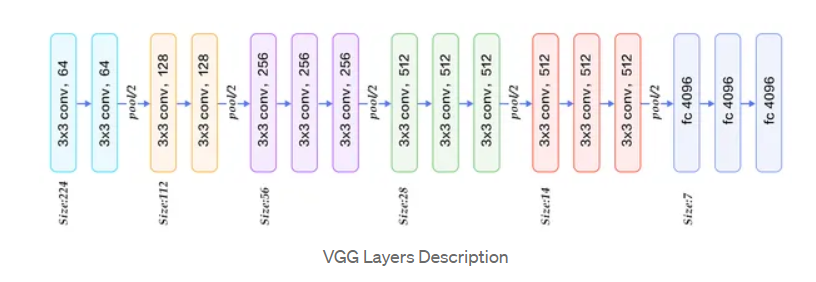

* **Convolution using 64 filters:**
This refers to a convolutional layer with 64 filters, typically using a small filter size like 3x3, and applying the filters to the input image.
* **Convolution using 64 filters + Max pooling:**
After the convolutional layer with 64 filters, a max-pooling layer is applied to down-sample the feature maps obtained from the convolutional layer.
* **Convolution using 128 filters:**
Another convolutional layer follows, this time with 128 filters, likely using the same filter size and stride.
* **Convolution using 128 filters + Max pooling:**
Similar to the previous step, a max-pooling layer is applied after the convolutional layer with 128 filters.
* **Convolution using 256 filters:**
Next, there is another convolutional layer with 256 filters.
* **Convolution using 256 filters:**
Following the previous convolutional layer, another convolutional layer with 256 filters is applied.
* **Convolution using 256 filters + Max pooling:**
Again, a max-pooling layer is applied after the two consecutive convolutional layers with 256 filters each.
* **Convolution using 512 filters:**
Subsequently, there is a convolutional layer with 512 filters.
* **Convolution using 512 filters:**
Another convolutional layer with 512 filters follows.
* **Convolution using 512 filters + Max pooling:**
After the two consecutive convolutional layers with 512 filters each, a max-pooling layer is applied.
* **Convolution using 512 filters:**
Then, there is another convolutional layer with 512 filters.
* **Convolution using 512 filters:**
Another convolutional layer with 512 filters is applied.
* **Convolution using 512 filters + Max pooling:**
Finally, after the two consecutive convolutional layers with 512 filters each, another max-pooling layer is applied.
* **Fully connected with 4096 nodes:**
The output of the convolutional layers is flattened, and the resulting feature vector is fed into a fully connected layer with 4096 nodes.
* **Fully connected with 4096 nodes:**
Another fully connected layer with 4096 nodes follows, typically followed by a softmax layer for classification in the case of VGG networks.

#### Basic code Implementation of VGG

In [ ]:
import tensorflow as tf

def vgg():
    model = tf.keras.Sequential()

    # Block 1
    # Convolutional layer with 64 filters, 3x3 kernel size, ReLU activation, and same padding
    model.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)))
    # Convolutional layer with 64 filters, 3x3 kernel size, ReLU activation, and same padding
    model.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    # Max pooling layer with 2x2 pool size and stride 2
    model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

    # Block 2
    # Convolutional layer with 128 filters, 3x3 kernel size, ReLU activation, and same padding
    model.add(tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    # Convolutional layer with 128 filters, 3x3 kernel size, ReLU activation, and same padding
    model.add(tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    # Max pooling layer with 2x2 pool size and stride 2
    model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

    # Block 3
    # Convolutional layer with 256 filters, 3x3 kernel size, ReLU activation, and same padding
    model.add(tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    # Convolutional layer with 256 filters, 3x3 kernel size, ReLU activation, and same padding
    model.add(tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    # Convolutional layer with 256 filters, 3x3 kernel size, ReLU activation, and same padding
    model.add(tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    # Max pooling layer with 2x2 pool size and stride 2
    model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

    # Block 4
    # Convolutional layer with 512 filters, 3x3 kernel size, ReLU activation, and same padding
    model.add(tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
    # Convolutional layer with 512 filters, 3x3 kernel size, ReLU activation, and same padding
    model.add(tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
    # Convolutional layer with 512 filters, 3x3 kernel size, ReLU activation, and same padding
    model.add(tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
    # Max pooling layer with 2x2 pool size and stride 2
    model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

    # Block 5
    # Convolutional layer with 512 filters, 3x3 kernel size, ReLU activation, and same padding
    model.add(tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
    # Convolutional layer with 512 filters, 3x3 kernel size, ReLU activation, and same padding
    model.add(tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
    # Convolutional layer with 512 filters, 3x3 kernel size, ReLU activation, and same padding
    model.add(tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
    # Max pooling layer with 2x2 pool size and stride 2
    model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

    # Flatten
    model.add(tf.keras.layers.Flatten())

    # Fully connected layers
    # Fully connected layer with 4096 units and ReLU activation
    model.add(tf.keras.layers.Dense(4096, activation='relu'))
    # Fully connected layer with 4096 units and ReLU activation
    model.add(tf.keras.layers.Dense(4096, activation='relu'))

    return model

# Instantiate the VGG model
model = vgg()

# Print model summary
model.summary()


### VGG16



The VGG16 model, short for Very Deep Convolutional Networks for Large-Scale Image Recognition, stands as a significant milestone in the realm of deep learning and computer vision. Proposed by A. Zisserman and K. Simonyan from the University of Oxford, VGG16 was introduced in their seminal paper titled "Very Deep Convolutional Networks for Large-Scale Image Recognition." This model garnered widespread acclaim for its remarkable performance, achieving nearly 92.7% top-5 test accuracy on the ImageNet dataset.

ImageNet, a dataset comprising over 14 million images distributed across nearly 1000 classes, serves as a benchmark for evaluating image classification models. VGG16's stellar performance on this dataset solidified its status as one of the leading architectures for image classification tasks. Notably, VGG16 was one of the most prominent models submitted to the ImageNet Large Scale Visual Recognition Challenge (ILSVRC) in 2014.

Key to its success is VGG16's innovative architecture, which replaces the large kernel-sized filters utilized in earlier models like AlexNet with multiple 3×3 kernel-sized filters stacked sequentially. This architectural tweak leads to significant improvements in performance and feature representation.

The VGG16 model comprises 16 layers, including convolutional and fully connected layers. With an image input size of 224-by-224, it is capable of classifying images into 1000 object categories, ranging from everyday objects like keyboards and pencils to various animals and more.

To train the VGG16 model, the researchers employed Nvidia Titan Black GPUs over the course of multiple weeks, highlighting the computational resources and time investment required for training deep neural networks of this scale.

VGG16 is object detection and classification algorithm which is able to classify 1000 images of 1000 different categories with 92.7% accuracy. It is one of the popular algorithms for image classification and is easy to use with transfer learning.

#### Architecture

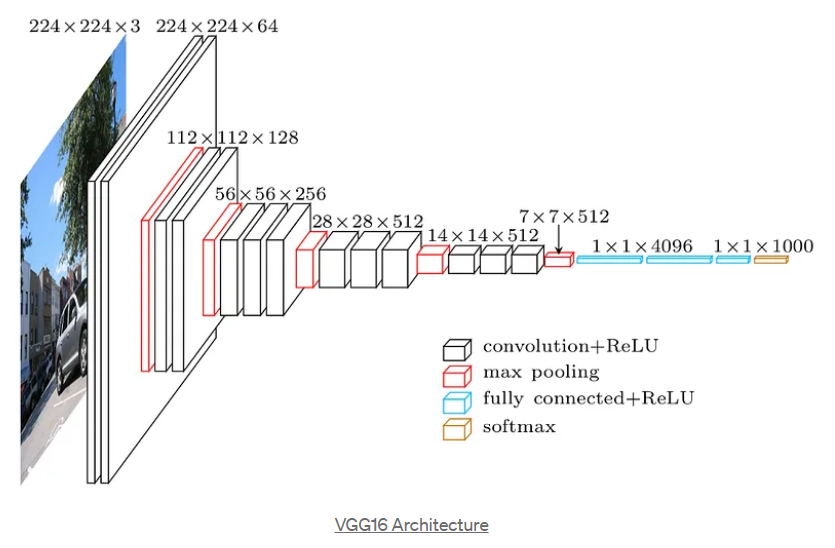

* **Input Layer:**
  * The input dimensions are 224x224 pixels with 3 color channels (RGB).
* **Convolutional Layers (64 filters, 3×3 filters, same padding):**
  * Two successive convolutional layers each use 64 filters with a filter size of 3x3.
  * Same padding is applied to ensure that the spatial dimensions remain the same after convolution.
* **Max Pooling Layer (2×2, stride 2):**
  * A max-pooling layer with a pool size of 2x2 and a stride of 2 is applied.
  * This layer reduces the spatial dimensions by a factor of 2.
* **Convolutional Layers (128 filters, 3×3 filters, same padding):**
  * Two successive convolutional layers each utilize 128 filters with a filter size of 3x3.
  * Same padding is applied to maintain spatial dimensions.
* **Max Pooling Layer (2×2, stride 2):**
  * Another max-pooling layer with a pool size of 2x2 and a stride of 2 is employed.
  * 8It reduces the spatial dimensions by a factor of 2.
* **Convolutional Layers (256 filters, 3×3 filters, same padding):**
  * Two successive convolutional layers each employ 256 filters with a filter size of 3x3.
  * Same padding is used to preserve spatial dimensions.
* **Convolutional Layers (512 filters, 3×3 filters, same padding):**
  * Two sets of three consecutive convolutional layers each utilize 512 filters with a filter size of 3x3.
  * Same padding is applied to maintain spatial dimensions.
* **Max Pooling Layer (2×2, stride 2):**
  * Another max-pooling layer with a pool size of 2x2 and a stride of 2 is employed.
  * It reduces the spatial dimensions by a factor of 2.
* **Stack of Convolutional Layers and Max Pooling:**
  * Two additional convolutional layers are added after the previous stack.
These layers utilize a filter size of 3x3.
* **Flattening:**
  * The output feature map, which has dimensions of 7x7x512, is flattened into a vector of size 25088.
* **Fully Connected Layers:**
  * Three fully connected layers are employed, each using ReLU activation.
  * The first layer has an input size of 25088 and an output size of 4096.
  * The second layer has an input size of 4096 and an output size of 4096.
  * The third layer has an input size of 4096 and an output size of 1000, corresponding to the 1000 classes in the ILSVRC challenge.
  * Softmax activation is applied to the output of the third fully connected layer for classification.

#### Basic code Implementation of VGG16

In [ ]:

import tensorflow as tf

def vgg16(input_shape=(224, 224, 3), num_classes=1000):
    model = tf.keras.Sequential([
        # Block 1
        # Convolutional layer with 64 filters, 3x3 kernel size, ReLU activation, and same padding
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        # Convolutional layer with 64 filters, 3x3 kernel size, ReLU activation, and same padding
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        # Max pooling layer with 2x2 pool size and stride 2
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

        # Block 2
        # Convolutional layer with 128 filters, 3x3 kernel size, ReLU activation, and same padding
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        # Convolutional layer with 128 filters, 3x3 kernel size, ReLU activation, and same padding
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        # Max pooling layer with 2x2 pool size and stride 2
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

        # Block 3
        # Convolutional layer with 256 filters, 3x3 kernel size, ReLU activation, and same padding
        tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        # Convolutional layer with 256 filters, 3x3 kernel size, ReLU activation, and same padding
        tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        # Convolutional layer with 256 filters, 3x3 kernel size, ReLU activation, and same padding
        tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        # Max pooling layer with 2x2 pool size and stride 2
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

        # Block 4
        # Convolutional layer with 512 filters, 3x3 kernel size, ReLU activation, and same padding
        tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        # Convolutional layer with 512 filters, 3x3 kernel size, ReLU activation, and same padding
        tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        # Convolutional layer with 512 filters, 3x3 kernel size, ReLU activation, and same padding
        tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        # Max pooling layer with 2x2 pool size and stride 2
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

        # Block 5
        # Convolutional layer with 512 filters, 3x3 kernel size, ReLU activation, and same padding
        tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        # Convolutional layer with 512 filters, 3x3 kernel size, ReLU activation, and same padding
        tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        # Convolutional layer with 512 filters, 3x3 kernel size, ReLU activation, and same padding
        tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        # Max pooling layer with 2x2 pool size and stride 2
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

        # Flatten the output feature map
        tf.keras.layers.Flatten(),

        # Fully connected layers
        # Fully connected layer with 4096 units and ReLU activation
        tf.keras.layers.Dense(4096, activation='relu'),
        # Fully connected layer with 4096 units and ReLU activation
        tf.keras.layers.Dense(4096, activation='relu'),
        # Output layer with num_classes units and softmax activation for classification
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Instantiate the VGG16 model
model = vgg16()

# Print model summary
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 64)      1792      
                                                                 
 conv2d_1 (Conv2D)           (None, 224, 224, 64)      36928     
                                                                 
 max_pooling2d (MaxPooling2  (None, 112, 112, 64)      0         
 D)                                                              
                                                                 
 conv2d_2 (Conv2D)           (None, 112, 112, 128)     73856     
                                                                 
 conv2d_3 (Conv2D)           (None, 112, 112, 128)     147584    
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 56, 56, 128)       0         
 g2D)                                                   

## Transfer Learning

Transfer learning in machine learning refers to the practice of leveraging knowledge gained from a previous task to enhance performance on a new, related problem. This approach allows a machine to apply insights acquired during one task to improve predictions in a different context. For instance, if a model has been trained to classify various types of beverages, it can utilize this learned information when tasked with identifying different types of cuisine. By transferring the knowledge acquired from prior training, the model can better discern patterns and features relevant to the new problem. Similarly, if a classifier has been trained to recognize backpacks in images, it can draw upon its training to identify other objects, such as sunglasses, with greater accuracy.

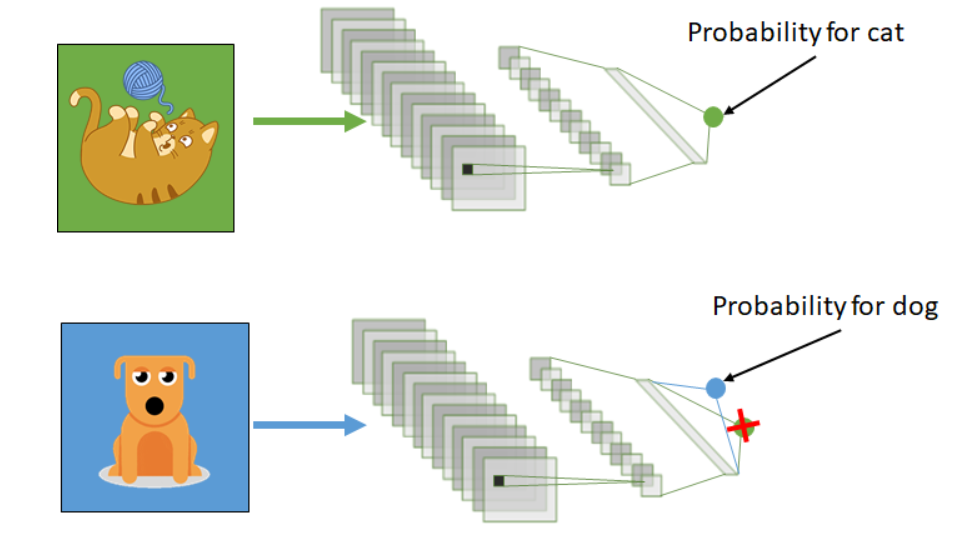

Transfer learning involves applying knowledge gained from one task to improve understanding of concepts in another task. In this process, the weights learned by a network while performing "task B" are automatically adapted to a network performing "task A." Transfer learning is commonly utilized in computer vision and natural language processing tasks, such as sentiment analysis, due to the substantial computational resources required for training.


#### How transfer learning works?


Transfer learning works by leveraging knowledge gained from solving one task and applying it to a related but different task. Here's a general overview of how transfer learning typically works:

* **Pretrained Model:** Start with a pretrained model that has been trained on a large dataset for a specific task, such as image classification or natural language processing. These pretrained models have learned to extract useful features from the data they were trained on.
* **Feature Extraction:** The pretrained model's architecture is typically composed of layers that gradually extract higher-level features from raw input data. In transfer learning, you can reuse these layers as feature extractors. By freezing the weights of these layers, you preserve the learned features.
* **Fine-Tuning:** After freezing the feature extraction layers, you add new layers (usually a few dense layers) on top of the pretrained model. These new layers are randomly initialized and then trained on your specific dataset for the target task. Optionally, you can also fine-tune some of the pretrained layers by unfreezing them and allowing their weights to be updated during training.
* **Training:** The entire model (pretrained layers + new layers) is then trained on the target dataset. Since the feature extraction layers have already learned useful features from the pretrained task, training on the new task requires fewer data and computational resources compared to training a model from scratch.
* **Transfer of Knowledge:** During training, the knowledge gained from solving the pretrained task is transferred to the new task. The model learns to extract features relevant to the new task from the input data, while still retaining the general patterns learned from the pretrained task.

#### Why should we use Transfer Learning


There are several compelling reasons to use transfer learning in machine learning tasks:

* **Limited Data:** Transfer learning is particularly beneficial when you have limited labeled data for your target task. By leveraging knowledge from a pretrained model trained on a large dataset, you can effectively transfer the learned features to your smaller dataset, improving model performance.
* **Reduced Training Time:** Training deep learning models from scratch on large datasets can be time-consuming and computationally expensive. Transfer learning allows you to start with a pretrained model that has already learned useful features, reducing the training time required for your specific task.
* **Improved Performance:** Transfer learning often leads to improved performance on the target task compared to training from scratch. The pretrained model has learned general features from a diverse dataset, which can capture relevant patterns and structures that are transferable to your task.
* **Domain Adaptation:** In scenarios where the source domain (pretrained task) and target domain (target task) are related but not identical, transfer learning can facilitate domain adaptation. By fine-tuning the pretrained model on the target domain data, the model can adapt its learned features to better suit the characteristics of the new dataset.
* **Resource Efficiency:** Leveraging pretrained models for transfer learning allows you to make the most of limited computational resources. Instead of training a deep model from scratch, you can use pretrained weights as a starting point, saving both time and computational power.
* **Addressing Specific Tasks:** Transfer learning enables you to address specific tasks even with limited data by building on the knowledge captured by models trained on broader tasks. This flexibility makes transfer learning applicable across various domains, including computer vision, natural language processing, and speech recognition.

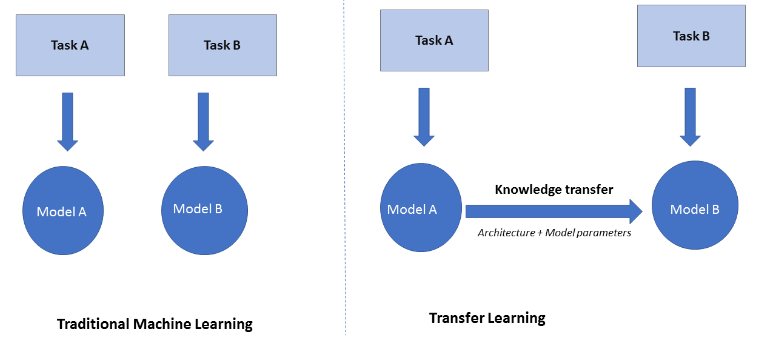

## Code Implementation

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


### Data Collection

In [ ]:
!kaggle datasets download -d salader/dogs-vs-cats

Dataset URL: https://www.kaggle.com/datasets/salader/dogs-vs-cats
License(s): unknown
 99% 1.05G/1.06G [00:06<00:00, 154MB/s]
100% 1.06G/1.06G [00:06<00:00, 181MB/s]


In [ ]:
import zipfile

# Open the zip file in read mode
zip_ref = zipfile.ZipFile('/content/dogs-vs-cats.zip', 'r')

# Extract all contents of the zip file into the specified directory
zip_ref.extractall('/content')

# Close the zip file
zip_ref.close()


### Libraries

In [ ]:
import tensorflow  # Import the TensorFlow library
from tensorflow import keras  # Import the Keras API from TensorFlow
from keras import Sequential  # Import the Sequential model from Keras
from keras.layers import Dense, Flatten  # Import specific layer types from Keras
from keras.applications.vgg16 import VGG16  # Import the VGG16 pre-trained model from Keras


In [ ]:
# Create a VGG16 convolutional base
conv_base = VGG16(
    weights='imagenet',    # Use pre-trained weights from ImageNet dataset
    include_top=False,     # Exclude the fully connected layers at the top of the network
    input_shape=(150, 150, 3)  # Define the input shape for the model (height, width, channels)
)


In [ ]:
conv_base.summary()

### Model

In [ ]:
# Create a Sequential model
model = Sequential()

# Add the VGG16 convolutional base to the model
model.add(conv_base)

# Flatten the output of the convolutional base before passing it to the dense layers
model.add(Flatten())

# Add a dense layer with 256 units and ReLU activation function
model.add(Dense(256, activation='relu'))

# Add the output layer with 1 unit and sigmoid activation function for binary classification
model.add(Dense(1, activation='sigmoid'))


In [ ]:
model.summary()

In [ ]:
# Freeze the weights of the convolutional base (VGG16)
conv_base.trainable = False

In [ ]:
# Training dataset: load images from the '/content/train' directory
train_ds = keras.utils.image_dataset_from_directory(
    directory='/content/train',  # Directory containing training images
    labels='inferred',           # Automatically infer labels from subdirectory names
    label_mode='int',            # Labels are represented as integers
    batch_size=32,               # Batch size for training
    image_size=(150, 150)        # Resize images to have height and width of 150 pixels
)

# Validation dataset: load images from the '/content/test' directory
validation_ds = keras.utils.image_dataset_from_directory(
    directory='/content/test',   # Directory containing validation images
    labels='inferred',           # Automatically infer labels from subdirectory names
    label_mode='int',            # Labels are represented as integers
    batch_size=32,               # Batch size for validation
    image_size=(150, 150)        # Resize images to have height and width of 150 pixels
)


In [ ]:
# Define a function to normalize images
def process(image, label):
    # Convert image pixel values to floats and normalize to [0, 1]
    image = tensorflow.cast(image / 255., tensorflow.float32)
    return image, label

# Apply the process function to normalize the training dataset
train_ds = train_ds.map(process)

# Apply the process function to normalize the validation dataset
validation_ds = validation_ds.map(process)

In [ ]:
# Compile the model with Adam optimizer, binary crossentropy loss, and accuracy metric
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
# Train the model on the training dataset for 10 epochs, validating on the validation dataset
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
429/625 [===================>..........] - ETA: 27:18 - loss: 0.2817 - accuracy: 0.8787

In [ ]:
import matplotlib.pyplot as plt

# Plot training accuracy (red) and validation accuracy (blue)
plt.plot(history.history['accuracy'], color='red', label='Train')
plt.plot(history.history['val_accuracy'], color='blue', label='Validation')

# Add legend
plt.legend()

# Show the plot
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Plot training loss (red) and validation loss (blue)
plt.plot(history.history['loss'], color='red', label='Train')
plt.plot(history.history['val_loss'], color='blue', label='Validation')

# Add legend
plt.legend()

# Show the plot
plt.show()
